# PCA for dimensionality reduction on Salinity and Temperature (ST) data - GMM clustering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import plotly.express as px
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]

In [3]:
# Define random seed for reproducibility
seed = 22

In [4]:
# Scale data
scaler = StandardScaler()
scaled_ST = scaler.fit_transform(df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']])

In [5]:
# Use PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(scaled_ST)

In [12]:
# How much variance is explained by each component
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each component: {explained_variance}')

Explained variance by each component: [0.68396019 0.31603981]


Text(0, 0.5, 'Principal Component 2')

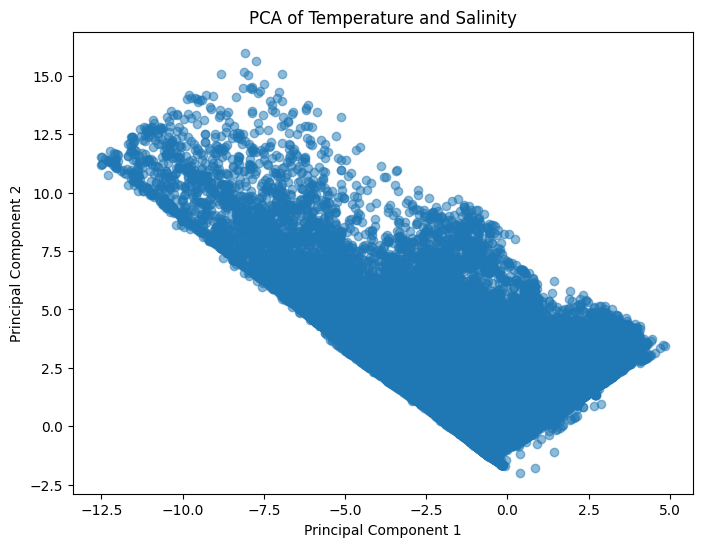

In [13]:
# Plot pca space
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('PCA of Temperature and Salinity')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

In [6]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

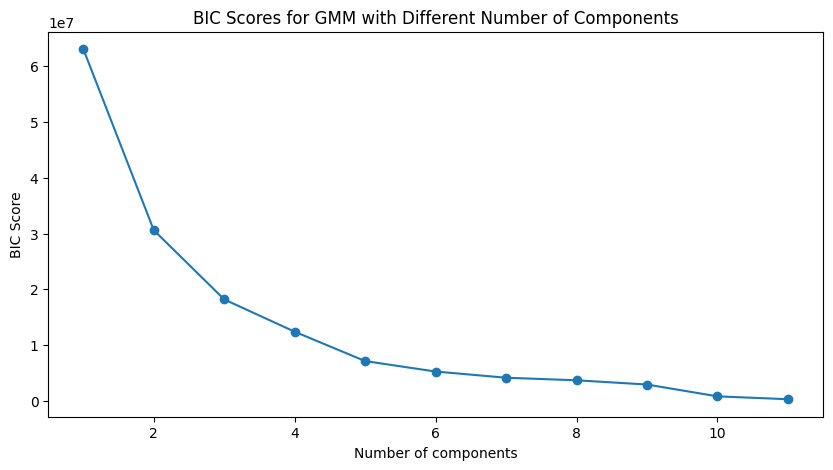

In [7]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [8]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 5

In [9]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(X_pca)

In [10]:
df_ST['gmm_labels'] = labels

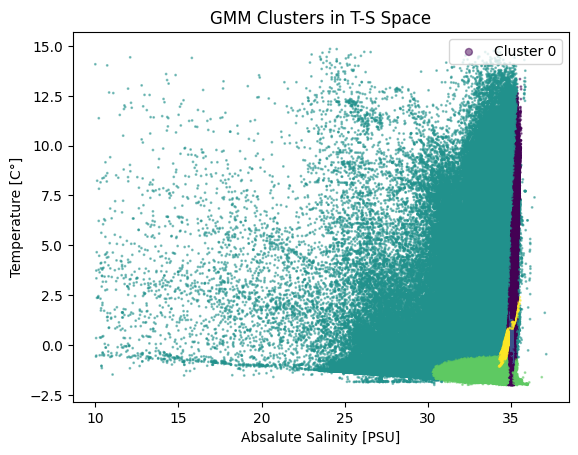

In [11]:
plt.scatter(df_ST['Absolute_Salinity_[PSU]'], df_ST['Conservative_Temperature_[deg_C]'], c=labels, s=1, alpha=0.5)
plt.xlabel("Absalute Salinity [PSU]")
plt.ylabel("Temperature [C°]")
plt.title("GMM Clusters in T-S Space")
#plt.legend(np.unique(labels), loc='upper left', markerscale=5)
plt.legend(loc='upper right', labels=[f'Cluster {i}' for i in range(optimal_n_components)], markerscale=5)
plt.show()